In [1]:
cd ~/work/tutorials/sources/OpenDrift/openberg_july2026

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_july2026


In [2]:
# import pandas as pd
# import xarray as xr
# import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import glob
from src.utils import *
from openberg_july2026.src2.utils0 import *
from openberg_july2026.src2.utils2 import *
from openberg_july2026.src2.utils3 import *

In [98]:
ib = 'iceberg2018b'
#read sim
file_contain_all = [ib,'idx','next']
file_contain_any = ['_']
file_notcontain = ['test','mainrun','prof',]#'test','wa','next','glorys']#['topaz4','glorys','slope','era5','almost','stokes',]
file_l = glob.glob("./results/results_idx/*.nc")#['./results/juliette_topaz6_topaz4_windglophynrt.nc',]
file_l = [f for f in file_l if all(ff in f for ff in file_contain_all)] #filtering for required keywords
file_l = [f for f in file_l if any(ff in f for ff in file_contain_any)] #filtering for required keywords
file_l = [f for f in file_l if all(ff not in f for ff in file_notcontain)] #filtering for neglected keywords
file_l = file_l[::-1]
file_dict_idx(file_l)

{'iceberg2018b_gebco_sisatdtu_nextsimre_windglophyre.nc': {'files': ['./results/results_idx/iceberg2018b_gebco_sisatdtu_nextsimre_windglophyre_idx1-2.nc',
   './results/results_idx/iceberg2018b_gebco_sisatdtu_nextsimre_windglophyre_idx3-4.nc',
   './results/results_idx/iceberg2018b_gebco_sisatdtu_nextsimre_windglophyre_idx5-6.nc',
   './results/results_idx/iceberg2018b_gebco_sisatdtu_nextsimre_windglophyre_idx7-7.nc'],
  'idx': [[1, 2], [3, 4], [5, 6], [7, 7]]},
 'iceberg2018b_gebco_nextsimre_windglophyre.nc': {'files': ['./results/results_idx/iceberg2018b_gebco_nextsimre_windglophyre_idx1-1.nc',
   './results/results_idx/iceberg2018b_gebco_nextsimre_windglophyre_idx2-2.nc',
   './results/results_idx/iceberg2018b_gebco_nextsimre_windglophyre_idx3-3.nc',
   './results/results_idx/iceberg2018b_gebco_nextsimre_windglophyre_idx4-4.nc',
   './results/results_idx/iceberg2018b_gebco_nextsimre_windglophyre_idx5-5.nc',
   './results/results_idx/iceberg2018b_gebco_nextsimre_windglophyre_idx6-6.n

In [99]:
#file_l for idx
fname = 'iceberg2018b_gebco_sisatdtu_nextsimre_windglophyre.nc'
file_l = file_dict_idx(file_l)[fname]['files']
idx_l = file_dict_idx(file_l)[fname]['idx']
print(fname,idx_l,file_l)

iceberg2018b_gebco_sisatdtu_nextsimre_windglophyre.nc [[1, 2], [3, 4], [5, 6], [7, 7]] ['./results/results_idx/iceberg2018b_gebco_sisatdtu_nextsimre_windglophyre_idx1-2.nc', './results/results_idx/iceberg2018b_gebco_sisatdtu_nextsimre_windglophyre_idx3-4.nc', './results/results_idx/iceberg2018b_gebco_sisatdtu_nextsimre_windglophyre_idx5-6.nc', './results/results_idx/iceberg2018b_gebco_sisatdtu_nextsimre_windglophyre_idx7-7.nc']


## Correct time in datasets


In [100]:
#load files
datasets = [xr.open_dataset(f) for f in file_l]

In [103]:
#check dims
print([sim.dims for sim in datasets])
[list(sim.time.values[np.array([0,-1])]) for sim in datasets]

[FrozenMappingWarningOnValuesAccess({'trajectory': 22, 'time': 960}), FrozenMappingWarningOnValuesAccess({'trajectory': 22, 'time': 960}), FrozenMappingWarningOnValuesAccess({'trajectory': 22, 'time': 960}), FrozenMappingWarningOnValuesAccess({'trajectory': 11, 'time': 480})]


[[np.datetime64('2018-12-31T00:00:00'), np.datetime64('2019-02-08T23:00:00')],
 [np.datetime64('2019-02-09T00:00:00'), np.datetime64('2019-03-20T23:00:00')],
 [np.datetime64('2019-03-21T00:00:00'), np.datetime64('2019-04-29T23:00:00')],
 [np.datetime64('2019-04-20T00:00:00'), np.datetime64('2019-05-09T23:00:00')]]

In [102]:
def clean_time(ds):
    ds = ds.copy()

    # remove seconds 
    ds = ds.assign_coords(
        time=ds.time.values.astype("datetime64[h]")
    )

    # remove any duplicate times created by the rounding
    _, idx = np.unique(ds.time.values, return_index=True)
    ds = ds.isel(time=np.sort(idx))

    # print(ds.time)

    return ds

datasets = [clean_time(sim) for sim in datasets]

In [44]:
# # common time - !NOT FOR file with diff time period
# common_time = datasets[0].time

# datasets = [
#     ds.reindex(time=common_time)
#     for ds in datasets
# ]

In [45]:
#save with cleaned time
# dataset[0].to_netcdf('./results/bla.nc')

## Combine and save ds


In [46]:
# #combine along dim run
# ds_combined = xr.concat(
#     datasets,
#     dim=xr.DataArray(
#         [f.split('/')[-1][:-3] for f in file_l],
#         dims="run",
#         name="run"
#     )
# )

In [106]:
#combine along dim time
n=11 #mainrun:1, n20:20
    #fix trajectory

datasets2 = [ds.assign_coords(trajectory=idxi[0]*n+ds.trajectory.values) for ds,idxi in zip(datasets,idx_l)]
    
ds_combined = xr.concat(
    datasets2,
    dim='time'
)

/tmp/ipykernel_42506/1558812852.py:7: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'trajectory' ('trajectory',) The recommendation is to set join explicitly for this case.
  ds_combined = xr.concat(


In [114]:
ds_combined = ds_combined.sortby('time')

In [116]:
#check for time sorting and doubles
ds_combined.time.to_index().is_monotonic_increasing,np.where(np.diff(ds_combined.time.values) <= np.timedelta64(0, 'ns'))[0]

(True,
 array([2640, 2642, 2644, 2646, 2648, 2650, 2652, 2654, 2656, 2658, 2660,
        2662, 2664, 2666, 2668, 2670, 2672, 2674, 2676, 2678, 2680, 2682,
        2684, 2686, 2688, 2690, 2692, 2694, 2696, 2698, 2700, 2702, 2704,
        2706, 2708, 2710, 2712, 2714, 2716, 2718, 2720, 2722, 2724, 2726,
        2728, 2730, 2732, 2734, 2736, 2738, 2740, 2742, 2744, 2746, 2748,
        2750, 2752, 2754, 2756, 2758, 2760, 2762, 2764, 2766, 2768, 2770,
        2772, 2774, 2776, 2778, 2780, 2782, 2784, 2786, 2788, 2790, 2792,
        2794, 2796, 2798, 2800, 2802, 2804, 2806, 2808, 2810, 2812, 2814,
        2816, 2818, 2820, 2822, 2824, 2826, 2828, 2830, 2832, 2834, 2836,
        2838, 2840, 2842, 2844, 2846, 2848, 2850, 2852, 2854, 2856, 2858,
        2860, 2862, 2864, 2866, 2868, 2870, 2872, 2874, 2876, 2878, 2880,
        2882, 2884, 2886, 2888, 2890, 2892, 2894, 2896, 2898, 2900, 2902,
        2904, 2906, 2908, 2910, 2912, 2914, 2916, 2918, 2920, 2922, 2924,
        2926, 2928, 2930, 2932,

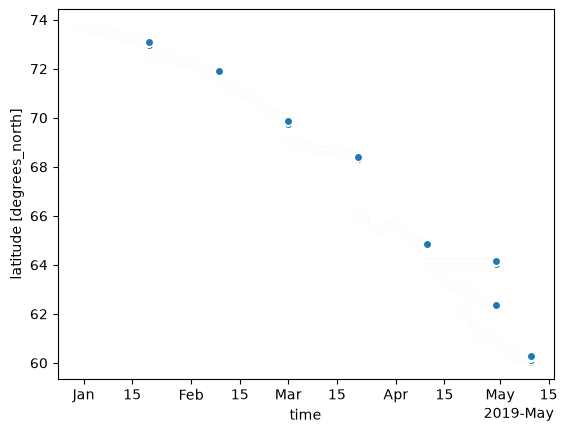

In [126]:
ds_combined.lat.plot.scatter(x='time',y='trajectory')
plt.show()

In [111]:
ds_combined.time[2878:2881]

<xarray.DataArray 'time' (time: 3)> Size: 24B
array(['2019-04-29T22:00:00', '2019-04-29T23:00:00', '2019-04-20T00:00:00'],
      dtype='datetime64[s]')
Coordinates:
  * time     (time) datetime64[s] 24B 2019-04-29T22:00:00 ... 2019-04-20

In [71]:
# ds_combined.lat.plot.scatter(x="time",y="trajectory")
ds_combined

In [87]:
outname = '_'.join(fname.split('_')[1:]).split('.')[0]
ds_combined.to_netcdf('./results/%s_%s_joined.nc'%(ib,outname))

In [ ]:
# # Join individual idx files
# fname = 'iceberg2018b_gebco_glorys_windglophyre_prof.nc'
# join_ds_by_idx(file_dict_idx(file_l)[fname]['files'])

# # # #if overlap in trajectories: subset, save, rejoin
# # # test = xr.open_dataset()
# # # test = test.sel(trajectory:np.arange())
# # # test.to_netcdf('.nc','w')

# # #test
# test = xr.open_dataset('./results/'+fname.replace('.nc','_joined.nc'))
# print(np.all(np.isnan(sim.lat.values)), test.trajectory.values)
# test.x_sea_water_velocity.plot()